In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [6]:
with h5py.File('finite_difference_results.h5', 'r') as hf:
    dx_values = np.array(hf['dx_values'])
    first_order_errors = np.array(hf['first_order_errors'])
    central_errors = np.array(hf['central_errors'])

In [7]:
slope_first_order = np.polyfit(np.log10(dx_values), np.log10(first_order_errors), 1)[0]
slope_central = np.polyfit(np.log10(dx_values), np.log10(central_errors), 1)[0]

print(f"Forward Difference Order: {slope_first_order:.2f}")
print(f"Central Difference Order: {slope_central:.2f}")

Forward Difference Order: 1.00
Central Difference Order: 1.93


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_168471/3857235367.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(dx_values, ref_y_1st, 'k--', alpha=0.5, label='Theoretical $\mathcal{O}(\Delta x)$')
/tmp/ipykernel_168471/3857235367.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(dx_values, ref_y_2nd, 'r--', alpha=0.5, label='Theoretical $\mathcal{O}(\Delta x^2)$')


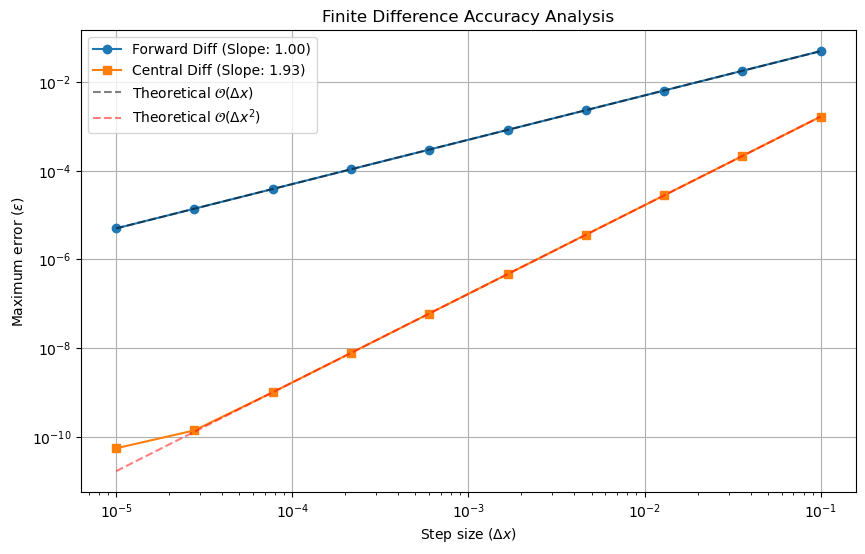

In [8]:
plt.figure(figsize=(10, 6))
plt.loglog(dx_values, first_order_errors, 'o-', label=f'Forward Diff (Slope: {slope_first_order:.2f})')
plt.loglog(dx_values, central_errors, 's-', label=f'Central Diff (Slope: {slope_central:.2f})')

# Add theoretical reference lines
ref_y_1st = dx_values * (first_order_errors[-1] / dx_values[-1])
plt.loglog(dx_values, ref_y_1st, 'k--', alpha=0.5, label='Theoretical $\mathcal{O}(\Delta x)$')

ref_y_2nd = (dx_values**2) * (central_errors[-1] / (dx_values[-1]**2))
plt.loglog(dx_values, ref_y_2nd, 'r--', alpha=0.5, label='Theoretical $\mathcal{O}(\Delta x^2)$')

plt.xlabel(r'Step size ($\Delta x$)')
plt.ylabel(r'Maximum error ($\epsilon$)')
plt.title('Finite Difference Accuracy Analysis')
plt.legend()
plt.grid(True)
plt.show()

<font color='red'>

$\textbf{Forward difference}$: The calculated slope of the error curve is $\approx 1$. That is, as $\Delta x$ decreases by a factor of 10, the error decreases by a factor of 10, meaning it is first-order accurate ($\mathcal{O}(\Delta x)$).

$\textbf{Central difference}$: The calculated slope of the error curve is $\approx 2$. That is, as $\Delta x$ decreases by a factor of 10, the error decreases by a factor of 100, meaning it is first-order accurate ($\mathcal{O}(\Delta x^2)$).


</font>